In [1]:
import pandas as pd
import numpy as np
import pandas_ta as ta
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import joblib

In [2]:
df = pd.read_csv('XAGUSD_M15_updated.csv', parse_dates=["Date"], index_col=0)

In [3]:
# target calculation
df['returns'] = df['Close'].pct_change()
df['target'] = (df['returns'] > 0).astype(int)
df['s_returns'] = df['returns']
df['cumulative_buy_and_hold_returns'] = df["returns"].cumsum().apply(np.exp)

# Shift price and returns to prevent lookahead bias
df['Close'] = df['Close'].shift(1)
df['Open'] = df['Open'].shift(1)
df['High'] = df['High'].shift(1)
df['Low'] = df['Low'].shift(1)
df['returns'] = df['returns'].shift(1)
df['volatility'] = df['returns'].rolling(window=8).std()
df['returns_div_volatility'] = df['returns'] / df['volatility'].replace(0, np.nan)
df['returns_inv'] = 1 / df['returns'].replace(0, np.nan)
df['volatility_inv'] = 1 / df['volatility'].replace(0, np.nan)
# df[['stoch_k', 'stoch_d']] = ta.stoch(df['High'], df['Low'], df['Close'], 13, 3, 3)
# df['stoch'] = np.where(
#     (df['stoch_k'] > df['stoch_d']) & (df['stoch_k'] <= 20), 1,
#     np.where((df['stoch_k'] < df['stoch_d']) & (df['stoch_k'] >= 80), -1, 0)
# )

df[["lower", "mid","upper","bandwidth","percent"]] = ta.bbands(df["Close"], length=21, std=2)
df['distance'] = df['Close'] - df['mid']
df["position"] = np.where(df.Close < df.lower, 1, np.nan) # 1. oversold -> go long
df["position"] = np.where(df.Close > df.upper, -1, df["position"]) # 2. overbought -> go short
df["position"] = np.where(df.distance * df.distance.shift(1) < 0, 0, df["position"]) # 3. crossing SMA ("Middle Band") -> go neutral
df["position"] = df.position.ffill().fillna(0)
df.dropna(inplace=True)

#HMM
feature_matrix = df[['returns', 'volatility']]
scaler_hmm = StandardScaler()
feature_matrix_scaled = scaler_hmm.fit_transform(feature_matrix)
hmm_model = GaussianHMM(n_components = 5, covariance_type="full", n_iter = 100 , random_state=42)
hmm_model.fit(feature_matrix_scaled)
df['hmm_regime'] = hmm_model.predict(feature_matrix_scaled)
probabilities = hmm_model.predict_proba(feature_matrix_scaled)
df['hmm_prob_0'] = probabilities[:, 0]
df['hmm_prob_1'] = probabilities[:, 1]
df['hmm_prob_2'] = probabilities[:, 2]
df['hmm_prob_3'] = probabilities[:, 3]
df['hmm_prob_4'] = probabilities[:, 4]

# Final clean up
df.replace([np.inf, -np.inf], 0, inplace=True)
df.dropna(inplace=True)

In [4]:
# features
features = df.drop(columns=['target', 's_returns', 'cumulative_buy_and_hold_returns', 'Close', 'Open', 'High', 'Low',"lower", "mid","upper","bandwidth","percent",'distance', 'position']).columns

# Define features and target
X = df[features]
y = df["target"]

# Apply StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Convert the scaled NumPy array back to a DataFrame
X = pd.DataFrame(X, columns=features)

In [5]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_clf = RandomForestClassifier(n_estimators=500,
                                max_depth=5,
                                class_weight = 'balanced',
                                random_state=42)

model = rf_clf

# Train the model on the training set
model.fit(X_train, y_train)

# Predict and calculate accuracy for training and testing sets
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

accuracy_train = accuracy_score(y_train, y_pred_train) * 100
accuracy_test = accuracy_score(y_test, y_pred_test) * 100

# Print train and test accuracy
print(f"Train Accuracy: {accuracy_train:.2f}")
print(f"Test Accuracy: {accuracy_test:.2f}")

# Predict on the entire dataset
df['pred'] = model.predict(X)
total_accuracy = accuracy_score(df.target, df.pred) * 100
print(f"Total Accuracy: {total_accuracy:.2f}")

# Get predicted probabilities for each class
probs = model.predict_proba(X)

# Add these probabilities to the dataframe
df['prob_class_-1'] = probs[:, 0]
df['prob_class_1'] = probs[:, 1]
df['prob'] = np.where(df['prob_class_1'] > df['prob_class_-1'], df['prob_class_1'], df['prob_class_-1'])

Train Accuracy: 55.12
Test Accuracy: 54.15
Total Accuracy: 54.92


In [6]:
X_wlr_th = 0.932
X_raw_accuracy_th = 54
X_filtered_accuracy_th = 58
X_sharp_ratio_th = 12
X_max_dd_th = 0.18
X_position_count_th = 19000
X_cumulative_th = 50
X_annual_th = 5

In [7]:
objects_to_save = {
    'clf': model,
    'hmm': hmm_model,
    'scaler': scaler,
    'scaler_hmm': scaler_hmm,
    'wlr': X_wlr_th,
    'raw_accuracy': X_raw_accuracy_th,
    'filtered_accuracy': X_filtered_accuracy_th,
    'sharp_ratio': X_sharp_ratio_th,
    'max_dd': X_max_dd_th,
    'position_count': X_position_count_th,
    'cumulative': X_cumulative_th,
    'annual' : X_annual_th}
joblib.dump(objects_to_save, 'U_XG.joblib')

['U_XG.joblib']

# Filter and Evaluations

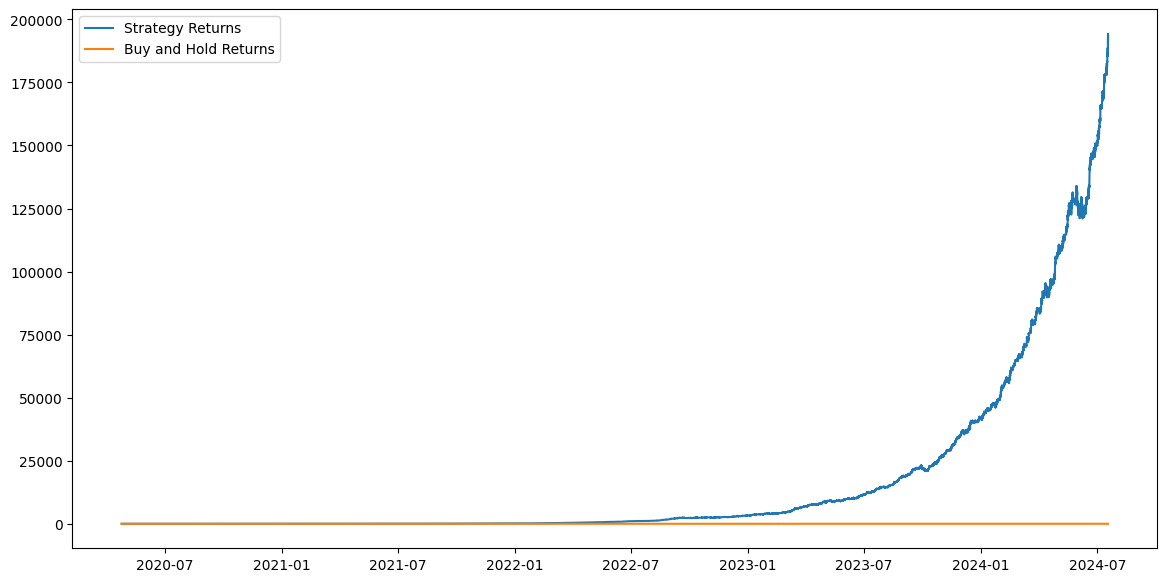

In [6]:
# strategy
df['pred'] = df['pred'].map({0: -1, 1: 1})
df['strategy'] = df['pred'] * df['s_returns']
df['cumulative_strategy_returns'] = df["strategy"].cumsum().apply(np.exp)

# plot
plt.figure(figsize=(14,7))
plt.plot(df['cumulative_strategy_returns'], label=f'Strategy Returns')
plt.plot(df['cumulative_buy_and_hold_returns'], label=f'Buy and Hold Returns')
plt.legend()
plt.show()

In [7]:
# Actual returns associated with each trade
annualized_factor = 24960  # The number of 15-minute bars in a year
annualized_sreturn = np.mean(df['strategy']) * annualized_factor
print(f"Annualized Strategy Return: {annualized_sreturn:.2f}")

# Sharpe Ratio
risk_free_rate = 0  # Assuming risk-free rate is 0 for simplicity
mean_return = np.mean(df['strategy']) * annualized_factor
std_return = np.std(df['strategy']) * np.sqrt(annualized_factor)
sharpe_ratio = (mean_return - risk_free_rate) / std_return
print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")


# Maximum Drawdown
def max_drawdown(strategy_returns):
    cumulative = np.cumsum(strategy_returns)
    drawdown = cumulative - np.maximum.accumulate(cumulative)
    return np.min(drawdown)

max_dd = max_drawdown(df['strategy'])
print(f"Maximum Drawdown: {max_dd:.2f}")

Annualized Strategy Return: 3.11
Annualized Sharpe Ratio: 9.43
Maximum Drawdown: -0.24


In [8]:
print(df.target.value_counts())
print(df.pred.value_counts())
print(df.position.value_counts())

target
0    49714
1    48123
Name: count, dtype: int64
pred
 1    49727
-1    48110
Name: count, dtype: int64
position
 0.0    45158
-1.0    26570
 1.0    26109
Name: count, dtype: int64


In [9]:
# Calculate wins and losses, treating losses as positive values
df['loss'] = np.where(df['strategy'] < 0, abs(df['strategy']), np.nan)
df['win'] = np.where(df['strategy'] > 0, df['strategy'], np.nan)

# Calculate the average win-to-loss ratio
win_loss_ratio = df['win'].mean() / df['loss'].mean()

# Handle cases where loss is zero or NaN
win_loss_ratio = np.where(np.isnan(win_loss_ratio) | (win_loss_ratio == 0), 1, win_loss_ratio)

# Calculate the Kelly Criterion using the improved formula
df['kelly'] = (df['prob'] - (1 - df['prob']) / win_loss_ratio)
win_loss_ratio

array(0.99046197)

In [10]:
df.describe()

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,hmm_prob_4,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
count,97837.000000,97837.000000,97837.000000,97837.000000,97837.000000,97837.000000,97837.000000,97837.000000,97837.000000,97837.000000,...,9.783700e+04,97837.000000,97837.000000,97837.000000,97837.000000,97837.000000,97837.000000,43168.000000,52609.000000,97837.000000
mean,23.652364,23.683172,23.620723,23.652569,0.000009,0.491869,0.000009,1.767462,0.001686,0.005277,...,2.810965e-01,0.016527,0.500086,0.499914,0.520990,0.000124,16291.875901,0.001362,0.001349,0.037367
std,2.974988,2.979896,2.969251,2.974861,0.002099,0.499936,0.002089,0.259701,0.001249,1.035518,...,4.245137e-01,0.999869,0.032275,0.032275,0.024517,0.002085,34542.910038,0.001754,0.001500,0.049270
min,14.719000,14.766000,14.588000,14.719000,-0.051246,0.000000,-0.051246,0.966953,0.000099,-3.932411,...,0.000000e+00,-1.000000,0.279247,0.166986,0.500000,-0.051246,0.985146,0.000031,0.000031,-0.004815
25%,22.343000,22.371000,22.317000,22.343000,-0.000863,0.000000,-0.000843,1.649012,0.000913,-0.674899,...,3.960270e-15,-1.000000,0.483694,0.486263,0.507189,-0.000691,18.947992,0.000380,0.000424,0.009632
50%,23.723000,23.752000,23.694000,23.723000,0.000039,0.000000,0.000000,1.794321,0.001361,0.023583,...,1.374717e-05,1.000000,0.499596,0.500404,0.515007,0.000132,777.261369,0.000835,0.000927,0.025344
75%,25.287000,25.324000,25.253000,25.288000,0.000895,1.000000,0.000879,1.877995,0.002068,0.690873,...,8.181119e-01,1.000000,0.513737,0.516306,0.524254,0.001019,11199.059029,0.001672,0.001768,0.043926
max,32.386000,32.500000,32.284000,32.390000,0.057645,1.000000,0.057645,2.613067,0.021030,4.791184,...,9.999998e-01,1.000000,0.833014,0.720753,0.833014,0.057645,194290.393698,0.051246,0.057645,0.664420


In [11]:
df_filtered = df[((df['position'] == 1) & (df['pred'] == 1)) | ((df['position'] == -1) & (df['pred'] == -1))].copy()

In [12]:
df_filtered

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,hmm_prob_4,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
Date,,,,,,,,,,,,,,,,,,,,,
2020-04-24 17:15:00,15.197,15.198,15.090,15.114,-0.005527,1,0.003242,0.994404,0.003601,-1.535027,...,2.711673e-66,1,0.463041,0.536959,0.536959,0.003242,1.004243,NaN,0.003242,0.069459
2020-04-24 17:45:00,15.163,15.196,15.152,15.180,0.001121,1,0.000066,0.995585,0.003611,0.310525,...,1.603070e-48,1,0.495476,0.504524,0.504524,0.000066,1.003184,NaN,0.000066,0.004277
2020-04-24 18:00:00,15.180,15.192,15.172,15.181,0.000066,0,-0.004677,0.990940,0.003273,0.020130,...,2.932096e-39,1,0.498201,0.501799,0.501799,-0.004677,0.998503,0.004677,NaN,-0.001199
2020-04-24 18:15:00,15.181,15.181,15.052,15.110,-0.004677,1,0.000463,0.991399,0.003566,-1.311511,...,7.989899e-61,1,0.463797,0.536203,0.536203,0.000463,0.998966,NaN,0.000463,0.067939
2020-04-24 18:30:00,15.110,15.140,15.058,15.117,0.000463,0,-0.001389,0.990023,0.003396,0.136404,...,3.132137e-42,1,0.497544,0.502456,0.502456,-0.001389,0.997579,0.001389,NaN,0.000121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-17 10:15:00,30.831,30.831,30.709,30.778,-0.001751,1,0.000845,2.505609,0.002066,-0.847697,...,4.200990e-16,1,0.472459,0.527541,0.527541,0.000845,188206.224929,NaN,0.000845,0.050532
2024-07-17 11:30:00,30.955,30.974,30.876,30.912,-0.001260,0,-0.000323,2.513601,0.001848,-0.681764,...,4.907239e-12,1,0.478567,0.521433,0.521433,-0.000323,187680.599395,0.000323,NaN,0.038257
2024-07-17 11:45:00,30.913,30.945,30.849,30.902,-0.000323,1,0.001909,2.518405,0.001744,-0.185504,...,7.091310e-10,1,0.488996,0.511004,0.511004,0.001909,188039.273036,NaN,0.001909,0.017299


In [13]:
df_filtered['pred'] = df_filtered['pred'].map({-1: 0, 1: 1})
accuracy = accuracy_score(df_filtered.target, df_filtered.pred) * 100
accuracy

55.77527775836769

In [14]:
print(df_filtered.target.value_counts())
print(df_filtered.pred.value_counts())
print(df_filtered.position.value_counts())

target
0    14344
1    14278
Name: count, dtype: int64
pred
1    14860
0    13762
Name: count, dtype: int64
position
 1.0    14860
-1.0    13762
Name: count, dtype: int64


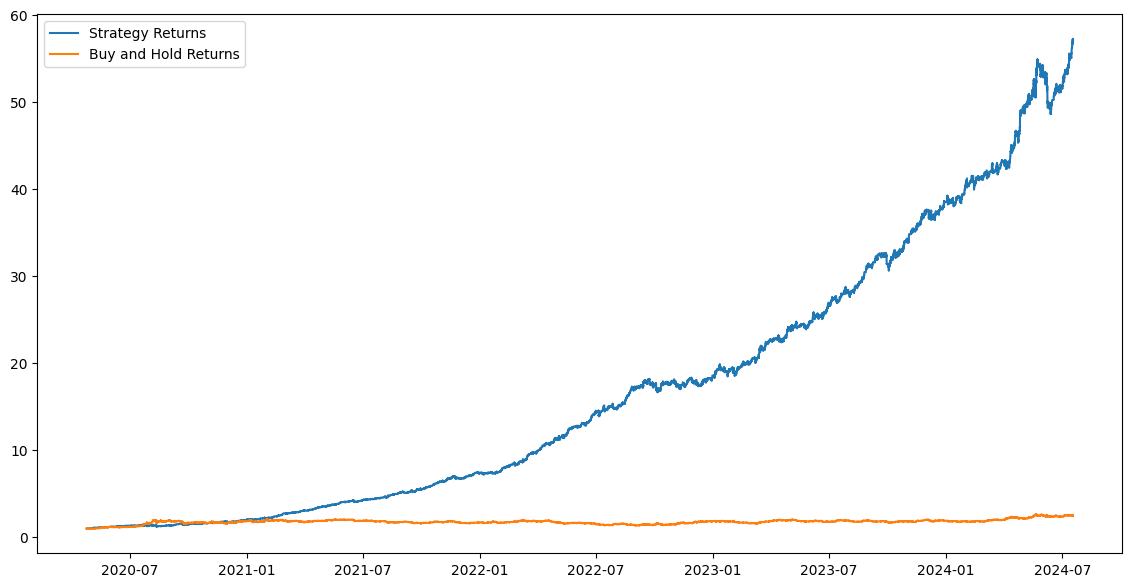

In [15]:
# strategy
df_filtered['pred'] = df_filtered['pred'].map({0: -1, 1: 1})
df_filtered['strategy'] = df_filtered['pred'] * df_filtered['s_returns']
df_filtered['cumulative_strategy_returns'] = df_filtered["strategy"].cumsum().apply(np.exp)

# plot
plt.figure(figsize=(14,7))
plt.plot(df_filtered['cumulative_strategy_returns'], label=f'Strategy Returns')
plt.plot(df_filtered['cumulative_buy_and_hold_returns'], label=f'Buy and Hold Returns')
plt.legend()
plt.show()

In [16]:
# Actual returns associated with each trade
annualized_factor = 24960  # The number of 15-minute bars in a year
annualized_sreturn = np.mean(df_filtered['strategy']) * annualized_factor
print(f"Annualized Strategy Return: {annualized_sreturn:.2f}")

# Sharpe Ratio
risk_free_rate = 0  # Assuming risk-free rate is 0 for simplicity
mean_return = np.mean(df_filtered['strategy']) * annualized_factor
std_return = np.std(df_filtered['strategy']) * np.sqrt(annualized_factor)
sharpe_ratio = (mean_return - risk_free_rate) / std_return
print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")


# Maximum Drawdown
def max_drawdown(strategy_returns):
    cumulative = np.cumsum(strategy_returns)
    drawdown = cumulative - np.maximum.accumulate(cumulative)
    return np.min(drawdown)

max_dd = max_drawdown(df_filtered['strategy'])
print(f"Maximum Drawdown: {max_dd:.2f}")

Annualized Strategy Return: 3.53
Annualized Sharpe Ratio: 9.47
Maximum Drawdown: -0.16


In [17]:
# Calculate wins and losses, treating losses as positive values
df_filtered['loss'] = np.where(df_filtered['strategy'] < 0, abs(df_filtered['strategy']), np.nan)
df_filtered['win'] = np.where(df_filtered['strategy'] > 0, df_filtered['strategy'], np.nan)

# Calculate the average win-to-loss ratio
win_loss_ratio = df_filtered['win'].mean() / df_filtered['loss'].mean()

# Handle cases where loss is zero or NaN
win_loss_ratio = np.where(np.isnan(win_loss_ratio) | (win_loss_ratio == 0), 1, win_loss_ratio)

# Calculate the Kelly Criterion using the improved formula
df_filtered['kelly'] = (df_filtered['prob'] - (1 - df_filtered['prob']) / win_loss_ratio)
win_loss_ratio

array(0.95784187)

In [18]:
df_filtered.describe()

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,hmm_prob_4,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
count,28622.000000,28622.000000,28622.000000,28622.000000,28622.000000,28622.000000,28622.000000,28622.000000,28622.000000,28622.000000,...,2.862200e+04,28622.000000,28622.000000,28622.000000,28622.000000,28622.000000,28622.000000,12407.000000,15653.000000,28622.000000
mean,23.617801,23.652859,23.580264,23.617107,-0.000030,0.498847,0.000031,1.764558,0.001863,-0.002087,...,2.282349e-01,0.038362,0.497316,0.502684,0.522089,0.000141,16.772844,0.001564,0.001498,0.023143
std,2.990284,2.996342,2.983766,2.990631,0.002593,0.500007,0.002360,0.261156,0.001399,1.150214,...,3.963150e-01,0.999281,0.033011,0.033011,0.024678,0.002356,15.112504,0.002057,0.001628,0.050442
min,14.744000,14.767000,14.588000,14.719000,-0.050363,0.000000,-0.050363,0.969118,0.000114,-3.932411,...,0.000000e+00,-1.000000,0.279247,0.277485,0.500000,-0.050363,0.994409,0.000032,0.000032,-0.022007
25%,22.310000,22.338000,22.278250,22.306000,-0.001027,0.000000,-0.000914,1.647385,0.001002,-0.742992,...,1.455290e-19,-1.000000,0.480301,0.486322,0.508277,-0.000740,3.730836,0.000419,0.000476,-0.005089
50%,23.689000,23.720000,23.653000,23.686000,0.000040,0.000000,0.000000,1.791910,0.001498,0.024793,...,6.278280e-07,1.000000,0.499057,0.500943,0.515868,0.000177,12.707714,0.000924,0.001044,0.010427
75%,25.271000,25.315000,25.233750,25.270000,0.001042,1.000000,0.001011,1.876678,0.002284,0.738123,...,2.389071e-01,1.000000,0.513678,0.519699,0.525479,0.001161,25.735472,0.001911,0.001946,0.030073
max,32.259000,32.500000,32.249000,32.390000,0.057645,1.000000,0.027638,2.613067,0.020961,4.791184,...,9.999997e-01,1.000000,0.722515,0.720753,0.722515,0.027847,57.255542,0.050363,0.027847,0.432816


In [19]:
df

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,hmm_prob_4,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
Date,,,,,,,,,,,,,,,,,,,,,
2020-04-24 15:15:00,15.252,15.318,15.250,15.318,0.004327,0,-0.001958,1.002541,0.002698,1.603975,...,0.000000e+00,-1,0.511780,0.488220,0.511780,0.001958,1.001960,NaN,0.001958,0.018858
2020-04-24 15:30:00,15.318,15.323,15.268,15.288,-0.001958,1,0.003859,1.006418,0.002847,-0.687890,...,1.209320e-31,1,0.473142,0.526858,0.526858,0.003859,1.005835,NaN,0.003859,0.049160
2020-04-24 15:45:00,15.288,15.368,15.285,15.347,0.003859,0,-0.005213,1.001185,0.003017,1.279306,...,1.411840e-35,-1,0.507978,0.492022,0.507978,0.005213,1.011092,NaN,0.005213,0.011218
2020-04-24 16:00:00,15.347,15.371,15.262,15.267,-0.005213,0,-0.001114,1.000071,0.003639,-1.432542,...,1.099012e-65,1,0.464917,0.535083,0.535083,-0.001114,1.009966,0.001114,NaN,0.065688
2020-04-24 16:15:00,15.267,15.295,15.246,15.250,-0.001114,1,0.002098,1.002172,0.003651,-0.304958,...,7.186768e-52,1,0.479843,0.520157,0.520157,0.002098,1.012088,NaN,0.002098,0.035693
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-17 17:00:00,30.915,31.043,30.859,31.023,0.003493,0,-0.015891,2.483726,0.001817,1.922737,...,1.015437e-10,-1,0.517486,0.482514,0.517486,0.015891,192586.114325,NaN,0.015891,0.030325
2024-07-17 17:15:00,31.021,31.032,30.328,30.530,-0.015891,0,-0.002358,2.477876,0.006009,-2.644443,...,3.931091e-278,1,0.447477,0.552523,0.552523,-0.002358,192132.466684,0.002358,NaN,0.100737
2024-07-17 17:30:00,30.503,30.552,30.370,30.458,-0.002358,1,0.003513,2.486596,0.005864,-0.402157,...,2.462475e-150,1,0.473091,0.526909,0.526909,0.003513,192808.621620,NaN,0.003513,0.049261


In [20]:
df_filtered_2 = df_filtered[(df_filtered['kelly'] > 0)].copy()
df_filtered_2['pred'] = df_filtered_2['pred'].map({-1: 0, 1: 1})
accuracy = accuracy_score(df_filtered_2.target, df_filtered_2.pred) * 100
accuracy

57.94911734164071

In [21]:
df_filtered_2

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,hmm_prob_4,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
Date,,,,,,,,,,,,,,,,,,,,,
2020-04-24 17:15:00,15.197,15.198,15.090,15.114,-0.005527,1,0.003242,0.994404,0.003601,-1.535027,...,2.711673e-66,1,0.463041,0.536959,0.536959,0.003242,1.003247,NaN,0.003242,0.053538
2020-04-24 18:15:00,15.181,15.181,15.052,15.110,-0.004677,1,0.000463,0.991399,0.003566,-1.311511,...,7.989899e-61,1,0.463797,0.536203,0.536203,0.000463,0.999095,NaN,0.000463,0.051992
2020-04-24 18:45:00,15.117,15.117,15.053,15.096,-0.001389,0,-0.003312,0.986749,0.003348,-0.414894,...,1.992206e-42,1,0.478762,0.521238,0.521238,-0.003312,0.994409,0.003312,NaN,0.021404
2020-04-24 19:00:00,15.096,15.106,15.003,15.046,-0.003312,1,0.002060,0.988784,0.003042,-1.088805,...,6.088120e-39,1,0.466017,0.533983,0.533983,0.002060,0.996460,NaN,0.002060,0.047455
2020-04-27 04:30:00,15.233,15.292,15.233,15.263,0.002035,0,-0.002948,0.998068,0.001821,1.117452,...,3.622041e-10,0,0.519373,0.480627,0.519373,0.002948,0.999402,NaN,0.002948,0.017592
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-17 10:15:00,30.831,30.831,30.709,30.778,-0.001751,1,0.000845,2.505609,0.002066,-0.847697,...,4.200990e-16,1,0.472459,0.527541,0.527541,0.000845,56.964350,NaN,0.000845,0.034287
2024-07-17 11:30:00,30.955,30.974,30.876,30.912,-0.001260,0,-0.000323,2.513601,0.001848,-0.681764,...,4.907239e-12,1,0.478567,0.521433,0.521433,-0.000323,56.945926,0.000323,NaN,0.021802
2024-07-17 11:45:00,30.913,30.945,30.849,30.902,-0.000323,1,0.001909,2.518405,0.001744,-0.185504,...,7.091310e-10,1,0.488996,0.511004,0.511004,0.001909,57.054754,NaN,0.001909,0.000485


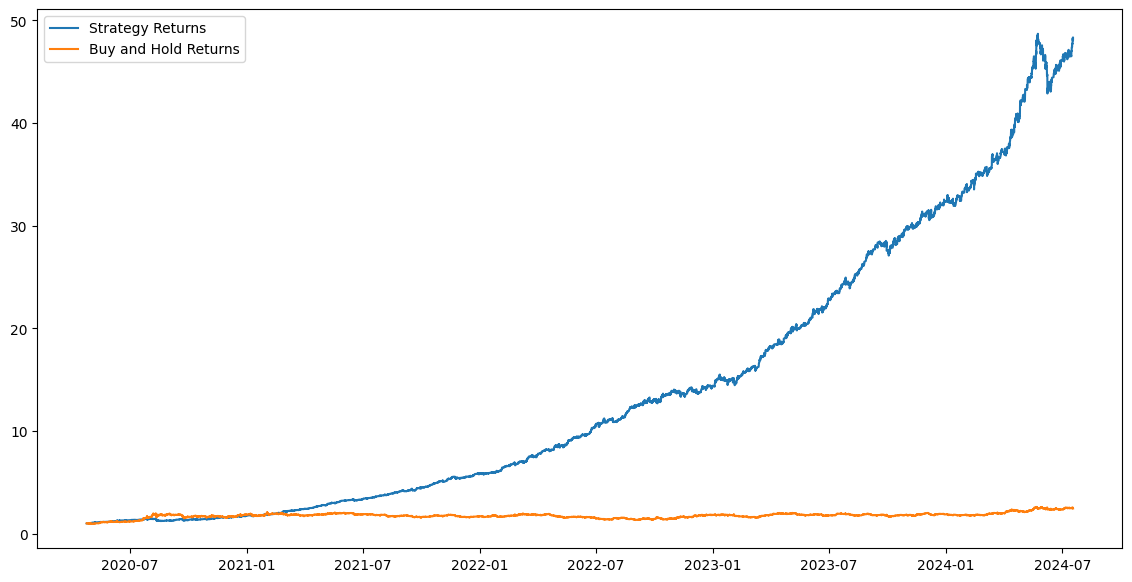

In [22]:
# strategy
df_filtered_2['pred'] = df_filtered_2['pred'].map({0: -1, 1: 1})
df_filtered_2['strategy'] = df_filtered_2['pred'] * df_filtered_2['s_returns']
df_filtered_2['cumulative_strategy_returns'] = df_filtered_2["strategy"].cumsum().apply(np.exp)

# plot
plt.figure(figsize=(14,7))
plt.plot(df_filtered_2['cumulative_strategy_returns'], label=f'Strategy Returns')
plt.plot(df_filtered_2['cumulative_buy_and_hold_returns'], label=f'Buy and Hold Returns')
plt.legend()
plt.show()

In [23]:
# Calculate wins and losses, treating losses as positive values
df_filtered_2['loss'] = np.where(df_filtered_2['strategy'] < 0, abs(df_filtered_2['strategy']), np.nan)
df_filtered_2['win'] = np.where(df_filtered_2['strategy'] > 0, df_filtered_2['strategy'], np.nan)

# Calculate the average win-to-loss ratio
win_loss_ratio = df_filtered_2['win'].mean() / df_filtered_2['loss'].mean()

# Handle cases where loss is zero or NaN
win_loss_ratio = np.where(np.isnan(win_loss_ratio) | (win_loss_ratio == 0), 1, win_loss_ratio)

# Calculate the Kelly Criterion using the improved formula
df_filtered_2['kelly'] = (df_filtered_2['prob'] - (1 - df_filtered_2['prob']) / win_loss_ratio)
win_loss_ratio

array(0.93240323)

In [24]:
# Actual returns associated with each trade
annualized_factor = 24960  # The number of 15-minute bars in a year
annualized_sreturn = np.mean(df_filtered_2['strategy']) * annualized_factor
print(f"Annualized Strategy Return: {annualized_sreturn:.2f}")

# Sharpe Ratio
risk_free_rate = 0  # Assuming risk-free rate is 0 for simplicity
mean_return = np.mean(df_filtered_2['strategy']) * annualized_factor
std_return = np.std(df_filtered_2['strategy']) * np.sqrt(annualized_factor)
sharpe_ratio = (mean_return - risk_free_rate) / std_return
print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")


# Maximum Drawdown
def max_drawdown(strategy_returns):
    cumulative = np.cumsum(strategy_returns)
    drawdown = cumulative - np.maximum.accumulate(cumulative)
    return np.min(drawdown)

max_dd = max_drawdown(df_filtered_2['strategy'])
print(f"Maximum Drawdown: {max_dd:.2f}")

Annualized Strategy Return: 5.02
Annualized Sharpe Ratio: 12.89
Maximum Drawdown: -0.18
